# 04 - Inclined parallel plate and Zernike origin-field identification

This notebook demonstrates the experimental non-central benchmark introduced in
StereoComplex: an inclined parallel plate is used **only as a synthetic oracle**,
while the fitted model is a generic low-order Zernike field of ray origins
`O(u,v)`.

The goal is not to calibrate a glass plate. The goal is to answer a metrology
question:

> if the true stereo system is non-central, does identifying a generic
> rayfield `(O(u,v), d(u,v))` improve 3D reconstruction compared with a
> central stereo model?

This notebook is also the bridge toward the real target: **image-based
non-central calibration**. The current cells use synthetic 2D observations so
that the geometric identifiability question is isolated first. The final
section explains how the next bundle-adjustment experiment should move from
rendered images and OpenCV detections to the same unknown blocks used by the
full geometric BA: ray origins, ray directions, board poses, and the stereo rig.

For the full theory page and generated figures, see
`docs/PARALLEL_PLATE_ORIGIN_FIELD.md` or the compiled HTML page
`docs/_build/html/PARALLEL_PLATE_ORIGIN_FIELD.html`.


## 1. Geometry recap

The oracle ray produced by the inclined plate is

$$
\mathcal R_{\mathrm{oracle}}(u,v)=\left(I_2(u,v), d_{\mathrm{pinhole}}(u,v)\right).
$$

The point `I2` is the physical exit point of the ray. It is **not** set to zero.
That is what makes the generated data non-central.

The staged origin-only model does not know the plate parameters. It uses

$$
\mathcal R_{\mathrm{fit}}(u,v)=\left(O(u,v), d_{\mathrm{pinhole}}(u,v)\right),
$$

where `O(u,v)` is a Zernike field with the transverse gauge

$$
O(u,v)\cdot d(u,v)=0.
$$

Zero coefficients mean `O(u,v)=0`, which is the central stereo baseline.
The complete BA variant used below also identifies a smooth direction field

$$
d(u,v)=\operatorname{normalize}(d_0(u,v)+\delta d_\perp(u,v)).
$$


## 2. Why we start with geometric observations

The final objective is image-based calibration:

$$
\text{rendered stereo images}
\rightarrow
\text{ChArUco detections}
\rightarrow
\text{central initialization}
\rightarrow
\text{non-central bundle adjustment}.
$$

But starting there immediately makes failures ambiguous. A bad result could
come from rasterization, corner detection, central pose initialization, gauge
freedom, insufficient board coverage, or the non-central model itself.

This notebook therefore fixes the first layer:

- the oracle generates non-central stereo observations;
- the staged baseline fits only the origin field `O(u,v)`;
- the complete geometric BA then fits `O(u,v)`, `d(u,v)`, board poses, and
  the stereo rig;
- the result is compared to an oracle noisy-pixel floor.

If this layer failed, there would be no point debugging a larger bundle
adjustment. Since it succeeds, the next experiment can safely add image
rendering and OpenCV corner detections.


In [1]:
from pathlib import Path
import json
import numpy as np
from IPython.display import Image, display
from types import SimpleNamespace

import stereocomplex as sc


def find_repo_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "pyproject.toml").exists() and (path / "src" / "stereocomplex").exists():
            return path
    raise RuntimeError("Could not find the StereoComplex repository root")


ROOT = find_repo_root(Path.cwd())
ASSET_DIR = ROOT / "docs" / "assets" / "parallel_plate_origin_field"
print(f"Repository root: {ROOT}")


Repository root: /home/jeff/StereoComplex


## 3. Run the benchmark through the public experimental API

`run_parallel_plate_origin_field_benchmark` builds a small synthetic stereo rig,
generates board observations through two inclined plates, fits `O(u,v)`, and
returns reconstruction, oracle-noise, and rayfield comparison reports.


In [2]:
report = sc.run_parallel_plate_origin_field_benchmark(max_order=4, noise_std_px=0.05)

central = report.reconstruction_comparison.central
origin = report.reconstruction_comparison.with_origin_field
oracle_clean = report.oracle_floor.oracle_clean_pixels
oracle_noisy = report.oracle_floor.oracle_observed_pixels

print("Central stereo, forced wrong model")
print(f"  RMS 3D      : {central.rms_3d:.3f} mm")
print(f"  median 3D   : {central.median_3d:.3f} mm")
print(f"  P95 3D      : {central.p95_3d:.3f} mm")
print(f"  ray gap RMS : {central.ray_gap_rms:.4f} mm")

print("\nOracle rayfield")
print(f"  clean pixels RMS  : {oracle_clean.rms_3d:.3e} mm")
print(f"  noisy pixels RMS  : {oracle_noisy.rms_3d:.3f} mm")
print(f"  noisy pixels P95  : {oracle_noisy.p95_3d:.3f} mm")

print("\nWith identified O(u,v)")
print(f"  RMS 3D      : {origin.rms_3d:.3f} mm")
print(f"  median 3D   : {origin.median_3d:.3f} mm")
print(f"  P95 3D      : {origin.p95_3d:.3f} mm")
print(f"  ray gap RMS : {origin.ray_gap_rms:.4f} mm")

print("\nImprovement over central")
print(f"  RMS factor   : {report.reconstruction_comparison.improvement_rms_factor:.2f}x")
print(f"  median factor: {report.reconstruction_comparison.improvement_median_factor:.2f}x")
print(f"  P95 factor   : {report.reconstruction_comparison.improvement_p95_factor:.2f}x")


Central stereo, forced wrong model
  RMS 3D      : 2.310 mm
  median 3D   : 2.257 mm
  P95 3D      : 3.040 mm
  ray gap RMS : 0.1535 mm

Oracle rayfield
  clean pixels RMS  : 1.359e-11 mm
  noisy pixels RMS  : 0.801 mm
  noisy pixels P95  : 1.644 mm

With identified O(u,v)
  RMS 3D      : 0.784 mm
  median 3D   : 0.521 mm
  P95 3D      : 1.556 mm
  ray gap RMS : 0.0849 mm

Improvement over central
  RMS factor   : 2.94x
  median factor: 4.33x
  P95 factor   : 1.95x


## 4. Complete geometric BA: identify O(u,v), d(u,v), poses, and rig

The default benchmark above is deliberately staged: it optimizes only
`O(u,v)` while keeping directions and board poses fixed. The experimental BA
mode below turns on all non-central geometric unknown blocks:

$$
O(u,v),\qquad d(u,v),\qquad T_{\mathrm{board},i},\qquad T_{R\leftarrow L}.
$$

Pose and rig regularization are kept on purpose: planar non-central
calibration has gauge freedoms, and an unconstrained optimizer can trade board
motion, baseline, and rayfield deformation while preserving tiny point-to-ray
residuals. This is the standard engineering compromise for a stable first
image-observation BA: initialize from a central calibration, then optimize all
blocks with weak priors.


In [3]:
ba_report = sc.run_parallel_plate_origin_field_benchmark(
    max_order=3,
    noise_std_px=0.05,
    optimize_directions=True,
    optimize_board_poses=True,
    optimize_stereo_extrinsics=True,
    pose_regularization=10.0,
    rig_regularization=100.0,
)

ba = ba_report.reconstruction_comparison.with_origin_field
print("Complete geometric BA O+d+poses+rig")
print(f"  RMS 3D      : {ba.rms_3d:.3f} mm")
print(f"  median 3D   : {ba.median_3d:.3f} mm")
print(f"  P95 3D      : {ba.p95_3d:.3f} mm")
print(f"  ray gap RMS : {ba.ray_gap_rms:.4f} mm")
print(f"  fit residual RMS: {ba_report.fit_result.residual_rms:.4f} mm")
print(f"  rig translation  : {ba_report.fit_result.stereo_transform[:3, 3]}")
print(f"  field type  : {type(ba_report.fit_result.left_field).__name__}")


Complete geometric BA O+d+poses+rig
  RMS 3D      : 0.801 mm
  median 3D   : 0.491 mm
  P95 3D      : 1.588 mm
  ray gap RMS : 0.0831 mm
  fit residual RMS: 0.0804 mm
  rig translation  : [-9.00000141e+01 -4.41936747e-06 -1.34874623e-05]
  field type  : ZernikeRayField


In this synthetic setup the true direction field is still pinhole-like, because
a parallel plate preserves the outgoing direction. The BA therefore mostly uses
`d(u,v)` as a controlled degree of freedom: a well-regularized fit should not
need large direction changes. The important result is that the full
`O+d+poses+rig` solve reaches the same noise scale as the O-only fit and the
oracle noisy-pixel floor.


## 5. Render images, detect ChArUco, run the same complete BA

The previous cells used synthetic image coordinates directly. We now run the
actual front-end, first with raw OpenCV detections and then with the Ray2D
planar refinement:

$$
\text{non-central rayfield}
\rightarrow
\text{rendered ChArUco images with vignetting/blur/noise}
\rightarrow
\text{OpenCV detections}
\rightarrow
\text{optional Ray2D planar refinement}
\rightarrow
\text{BA over } O,d,\text{poses,rig}.
$$

This is harder than the geometric oracle because detector bias and
rasterization enter the observations. The benchmark uses a larger `12 x 9`
ChArUco target and 10 poses, following the usual practical rule of using
enough views and a target that occupies a substantial fraction of the image.
The target is no longer the ideal noisy oracle floor; the practical question is
whether the full BA approaches the **oracle detected** floor, i.e. the exact
rayfield evaluated at the pixels actually returned by the 2D front-end. This
distinction is essential: if the oracle detected floor is already bad, the
bottleneck is the front-end, not the non-central BA.


In [4]:
image_reports = {
    "OpenCV raw": sc.run_parallel_plate_rendered_image_benchmark(
        out_dir=ASSET_DIR / "rendered_image_ba" / "notebook_images_raw",
        max_order=3,
        method2d="raw",
    ),
    "Ray2D refined": sc.run_parallel_plate_rendered_image_benchmark(
        out_dir=ASSET_DIR / "rendered_image_ba" / "notebook_images_ray2d",
        max_order=3,
        method2d="rayfield_tps_robust",
    ),
}

print("Rendered-image ChArUco pipeline")
for label, image_report in image_reports.items():
    img_central = image_report.reconstruction_comparison.central
    img_oracle = image_report.oracle_detected
    img_ba = image_report.reconstruction_comparison.with_origin_field
    print(f"\n{label}")
    print(f"  method2d                : {image_report.method2d}")
    print(f"  frames                  : {image_report.n_frames}")
    print(f"  common corners / frame  : {image_report.n_common_corners}")
    print(f"  total point observations: {image_report.n_points_total}")
    print(f"  fit success             : {image_report.fit_result.success}")
    print(f"  fit residual RMS        : {image_report.fit_result.residual_rms:.3f} mm")
    print(f"  central RMS 3D          : {img_central.rms_3d:.3f} mm")
    print(f"  oracle detected RMS 3D  : {img_oracle.rms_3d:.3f} mm")
    print(f"  BA O+d+poses+rig RMS 3D : {img_ba.rms_3d:.3f} mm")
    print(f"  RMS improvement         : {image_report.reconstruction_comparison.improvement_rms_factor:.2f}x")

raw_ba = image_reports["OpenCV raw"].reconstruction_comparison.with_origin_field.rms_3d
ray2d_ba = image_reports["Ray2D refined"].reconstruction_comparison.with_origin_field.rms_3d
print(f"\nRay2D front-end gain over raw BA: {raw_ba / ray2d_ba:.2f}x")


Rendered-image ChArUco pipeline

OpenCV raw
  method2d                : raw
  frames                  : 10
  common corners / frame  : 59
  total point observations: 590
  fit success             : True
  fit residual RMS        : 0.382 mm
  central RMS 3D          : 4.213 mm
  oracle detected RMS 3D  : 3.440 mm
  BA O+d+poses+rig RMS 3D : 3.360 mm
  RMS improvement         : 1.25x

Ray2D refined
  method2d                : rayfield_tps_robust
  frames                  : 10
  common corners / frame  : 59
  total point observations: 590
  fit success             : True
  fit residual RMS        : 0.082 mm
  central RMS 3D          : 2.498 mm
  oracle detected RMS 3D  : 0.763 mm
  BA O+d+poses+rig RMS 3D : 0.658 mm
  RMS improvement         : 3.80x

Ray2D front-end gain over raw BA: 5.11x


## 6. Why the noisy result is not a failure

For this setup, a simple stereo uncertainty estimate is

$$
\sigma_Z \approx \frac{Z^2}{fB}\sqrt{2}\,\sigma_{px}.
$$

With $Z\approx 800\,\mathrm{mm}$, $f\approx 620\,\mathrm{px}$,
$B\approx 90\,\mathrm{mm}$ and $\sigma_{px}=0.05\,\mathrm{px}$, this gives
about $0.8\,\mathrm{mm}$.

That matches the benchmark: the exact oracle rayfield evaluated at noisy pixels
is around `0.80 mm` RMS, and the fitted `O(u,v)` field is around `0.78 mm` RMS.
So the noisy residual is mostly the pixel-noise floor, not evidence that the
origin-field model failed.


In [5]:
Z = 800.0
f = 620.0
B = 90.0
sigma_px = 0.05
sigma_z = (Z**2 / (f * B)) * np.sqrt(2.0) * sigma_px
print(f"Approximate stereo noise floor: {sigma_z:.3f} mm")


Approximate stereo noise floor: 0.811 mm


## 7. From measured rayfield to physical model: fitting a thin parallel plate

The previous sections fitted a generic Zernike rayfield. We now use that
fitted rayfield as a measured geometric object and ask a different question:

> can a low-dimensional physical model explain the measured non-central
> rayfield?

This is not the same as fitting the glass plate directly from ChArUco points.
The physical model is fitted **after** the generic rayfield has been
identified. This turns the optical inverse problem into a model-selection
problem in the space of 3D rays:

$$
\theta^\star =
\arg\min_\theta
D^2\left(
\widehat{\mathcal R}_Z,
\mathcal R_{\mathrm{plate}}(\theta)
\right).
$$

The distance $D$ is computed by intersecting both rayfields with two reference
planes:

$$
D^2 =
\sum_k
\left|A_Z^k-A_{\mathrm{plate}}^k\right|^2
+
\left|B_Z^k-B_{\mathrm{plate}}^k\right|^2,
\qquad
A=\mathcal R\cap\Pi_{z_0},\quad
B=\mathcal R\cap\Pi_{z_1}.
$$

Raw origins are never compared directly: the oracle keeps the physical exit
point `I2`, while the measured Zernike rayfield uses a transverse gauge. The
fitted physical parameters are only an interpretation of the measured rayfield.

For this step we deliberately use a wider-coverage synthetic dataset than the
compact default benchmark: a larger board and more eccentric poses. Since the
fitted plate is judged as a rayfield over the image, not only on the original
reconstruction points, the calibration support should explore as much of the
image as possible.


In [6]:
physical_dataset = sc.make_parallel_plate_wide_coverage_dataset(noise_std_px=0.0)
physical_config = sc.ZernikeOriginFieldConfig(image_size=physical_dataset.image_size, max_order=4)
physical_fit = sc.fit_stereo_zernike_origin_field(
    observations=physical_dataset,
    K_left=physical_dataset.K_left,
    K_right=physical_dataset.K_right,
    T_right_left_initial=physical_dataset.T_right_left,
    board_poses_initial=physical_dataset.board_poses,
    config_left=physical_config,
    config_right=physical_config,
    regularization=1e-3,
)

support_left = np.concatenate(physical_dataset.left_pixels, axis=0)
support_right = np.concatenate(physical_dataset.right_pixels, axis=0)

plate_fit_left = sc.fit_parallel_plate_to_zernike_rayfield(
    zernike_field=physical_fit.left_field,
    K=physical_dataset.K_left,
    image_size=physical_dataset.image_size,
    support_pixels=support_left,
    eta=1.5,
    z_planes=(100.0, 1000.0),
    grid_shape=(25, 19),
    oracle_params=physical_dataset.oracle_left_params,
)
plate_fit_right = sc.fit_parallel_plate_to_zernike_rayfield(
    zernike_field=physical_fit.right_field,
    K=physical_dataset.K_right,
    image_size=physical_dataset.image_size,
    support_pixels=support_right,
    eta=1.5,
    z_planes=(100.0, 1000.0),
    grid_shape=(25, 19),
    oracle_params=physical_dataset.oracle_right_params,
)

print("Physical plate fitted to measured Zernike rayfield")
for side, plate_fit in [("left", plate_fit_left), ("right", plate_fit_right)]:
    print(f"\n{side}")
    print(f"  alpha       : {plate_fit.params.alpha_deg:.3f} deg")
    print(f"  beta        : {plate_fit.params.beta_deg:.3f} deg")
    print(f"  thickness   : {plate_fit.params.thickness_mm:.3f} mm")
    print(f"  support RMS : {plate_fit.rayfield_rms_support_mm:.3f} mm")
    print(f"  full RMS    : {plate_fit.rayfield_rms_full_mm:.3f} mm")
    print(f"  param error : {plate_fit.parameter_error}")


Physical plate fitted to measured Zernike rayfield

left
  alpha       : 13.013 deg
  beta        : 5.005 deg
  thickness   : 15.982 mm
  support RMS : 0.002 mm
  full RMS    : 0.034 mm
  param error : {'alpha_deg': 0.012977853503880254, 'beta_deg': 0.005060953310708882, 'thickness_mm': -0.017810639528692107, 'eta': 0.0}

right
  alpha       : 10.044 deg
  beta        : 7.012 deg
  thickness   : 13.969 mm
  support RMS : 0.003 mm
  full RMS    : 0.054 mm
  param error : {'alpha_deg': 0.043718471997983954, 'beta_deg': 0.012450058873328729, 'thickness_mm': -0.031077057627289406, 'eta': 0.0}


In [7]:
plate_model = SimpleNamespace(
    left_field=sc.PinholeParallelPlateRayField(physical_dataset.K_left, plate_fit_left.params),
    right_field=sc.PinholeParallelPlateRayField(physical_dataset.K_right, plate_fit_right.params),
    stereo_transform=physical_dataset.T_right_left,
)
plate_comparison = sc.compare_3d_reconstruction_with_without_origin_field(
    dataset=physical_dataset,
    central_model_result=None,
    origin_field_result=plate_model,
)
zernike_physical_comparison = sc.compare_3d_reconstruction_with_without_origin_field(
    dataset=physical_dataset,
    central_model_result=None,
    origin_field_result=physical_fit,
)
oracle_physical_floor = sc.oracle_reconstruction_floor_report(physical_dataset).oracle_clean_pixels

print("3D reconstruction with compact physical plate model")
print(f"  central RMS       : {plate_comparison.central.rms_3d:.3f} mm")
print(f"  Zernike RMS       : {zernike_physical_comparison.with_origin_field.rms_3d:.3f} mm")
print(f"  fitted plate RMS  : {plate_comparison.with_origin_field.rms_3d:.3f} mm")
print(f"  oracle RMS        : {oracle_physical_floor.rms_3d:.3e} mm")
print(f"  fitted plate P95  : {plate_comparison.with_origin_field.p95_3d:.3f} mm")
print(f"  fitted plate gap  : {plate_comparison.with_origin_field.ray_gap_rms:.4f} mm")

zernike_params = physical_fit.left_field.coeffs.size + physical_fit.right_field.coeffs.size
print("\nModel complexity")
print(f"  Zernike origin field: {zernike_params} scalar coefficients")
print("  Fitted plate model  : 6 scalar parameters for two independent plates (eta fixed)")


3D reconstruction with compact physical plate model
  central RMS       : 2.540 mm
  Zernike RMS       : 0.003 mm
  fitted plate RMS  : 0.010 mm
  oracle RMS        : 1.296e-11 mm
  fitted plate P95  : 0.018 mm
  fitted plate gap  : 0.0006 mm

Model complexity
  Zernike origin field: 90 scalar coefficients
  Fitted plate model  : 6 scalar parameters for two independent plates (eta fixed)


The physical model is not expected to beat the generic Zernike rayfield on
training residuals. Its value is **compression and interpretability**: it tests
whether most of the measured non-central rayfield can be explained by a few
physical parameters.

In this benchmark the fitted plate is much more compact and still improves
strongly over the central model. Any remaining difference with the Zernike
field should be read as a model-selection residual: either the measured
rayfield is not perfectly constrained outside the observed support, or the
compact plate model extrapolates differently from the generic Zernike field.

This section illustrates the broader workflow:

> measure the rayfield first, then compare optical models in ray space.

In French: les points 2D servent à mesurer le champ de rayons ; le champ de
rayons sert ensuite à identifier l'optique.


### Noisy case, bootstrap and model selection diagnostics

The documentation generator also runs three additional checks:

1. the same physical compression with `0.05 px` observation noise;
2. a bootstrap refit on random subsets of the observed support;
3. a ray-space comparison against simpler or deliberately wrong physical
   candidates.

These are not new calibration algorithms. They are diagnostics for the
interpretation step. The key question is whether the compact plate remains at
the oracle noisy floor, and whether wrong physical candidates are rejected in
ray space.


In [8]:
for path in [
    ASSET_DIR / "physical_plate_noisy_summary.json",
    ASSET_DIR / "physical_plate_bootstrap.json",
    ASSET_DIR / "physical_plate_model_selection.json",
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run docs/examples/parallel_plate_origin_field_demo.py first."
        )

noisy_physical = json.loads((ASSET_DIR / "physical_plate_noisy_summary.json").read_text())
bootstrap_physical = json.loads((ASSET_DIR / "physical_plate_bootstrap.json").read_text())
model_selection = json.loads((ASSET_DIR / "physical_plate_model_selection.json").read_text())

print("Noisy physical compression at 0.05 px")
print(f"  central RMS      : {noisy_physical['central_rms_3d_mm']:.3f} mm")
print(f"  Zernike RMS      : {noisy_physical['zernike_rms_3d_mm']:.3f} mm")
print(f"  fitted plate RMS : {noisy_physical['plate_rms_3d_mm']:.3f} mm")
print(f"  oracle pixel RMS : {noisy_physical['oracle_observed_pixels_rms_3d_mm']:.3f} mm")

print("\nBootstrap parameter stability")
for side in ["left", "right"]:
    row = bootstrap_physical[side]
    print(
        f"  {side}: alpha={row['alpha_mean_deg']:.4f}+/-{row['alpha_std_deg']:.4f} deg, "
        f"beta={row['beta_mean_deg']:.4f}+/-{row['beta_std_deg']:.4f} deg, "
        f"e={row['thickness_mean_mm']:.4f}+/-{row['thickness_std_mm']:.4f} mm"
    )

print("\nRay-space model selection: average left/right full-grid RMS to Zernike")
for key in ["central", "fronto_parallel", "wrong_eta_fit", "inclined_plate_fit"]:
    row = model_selection[key]
    avg = 0.5 * (row["left_full_rms_to_zernike_mm"] + row["right_full_rms_to_zernike_mm"])
    print(f"  {key:18s}: {avg:.4f} mm")


Noisy physical compression at 0.05 px
  central RMS      : 2.615 mm
  Zernike RMS      : 0.744 mm
  fitted plate RMS : 0.751 mm
  oracle pixel RMS : 0.752 mm

Bootstrap parameter stability
  left: alpha=13.0045+/-0.0002 deg, beta=5.0018+/-0.0002 deg, e=15.9938+/-0.0003 mm
  right: alpha=10.0146+/-0.0007 deg, beta=7.0043+/-0.0003 deg, e=13.9894+/-0.0005 mm

Ray-space model selection: average left/right full-grid RMS to Zernike
  central           : 3.6948 mm
  fronto_parallel   : 1.9621 mm
  wrong_eta_fit     : 0.0976 mm
  inclined_plate_fit: 0.0441 mm


## 8. Show the generated figures

The figure-generation script is:

```bash
.venv/bin/python docs/examples/parallel_plate_origin_field_demo.py
```

It writes the PNG files used by the documentation page.


reconstruction_error_distributions.png


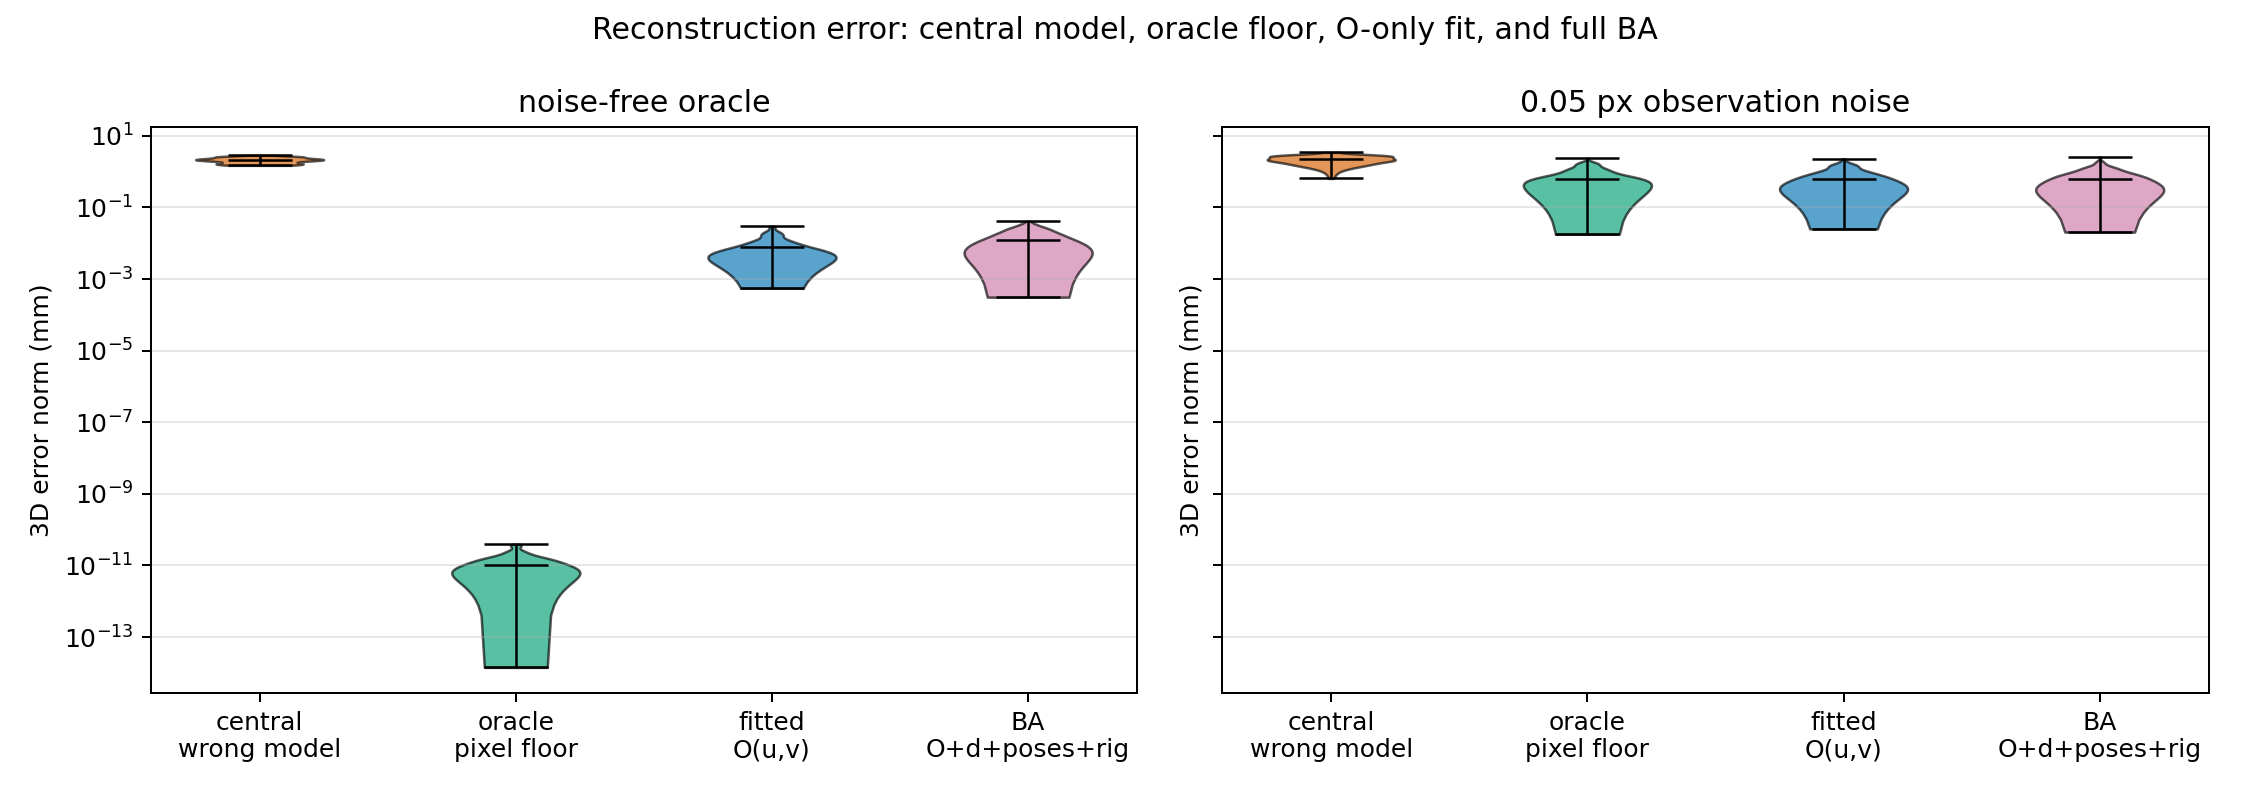

physical_plate_reconstruction_comparison.png


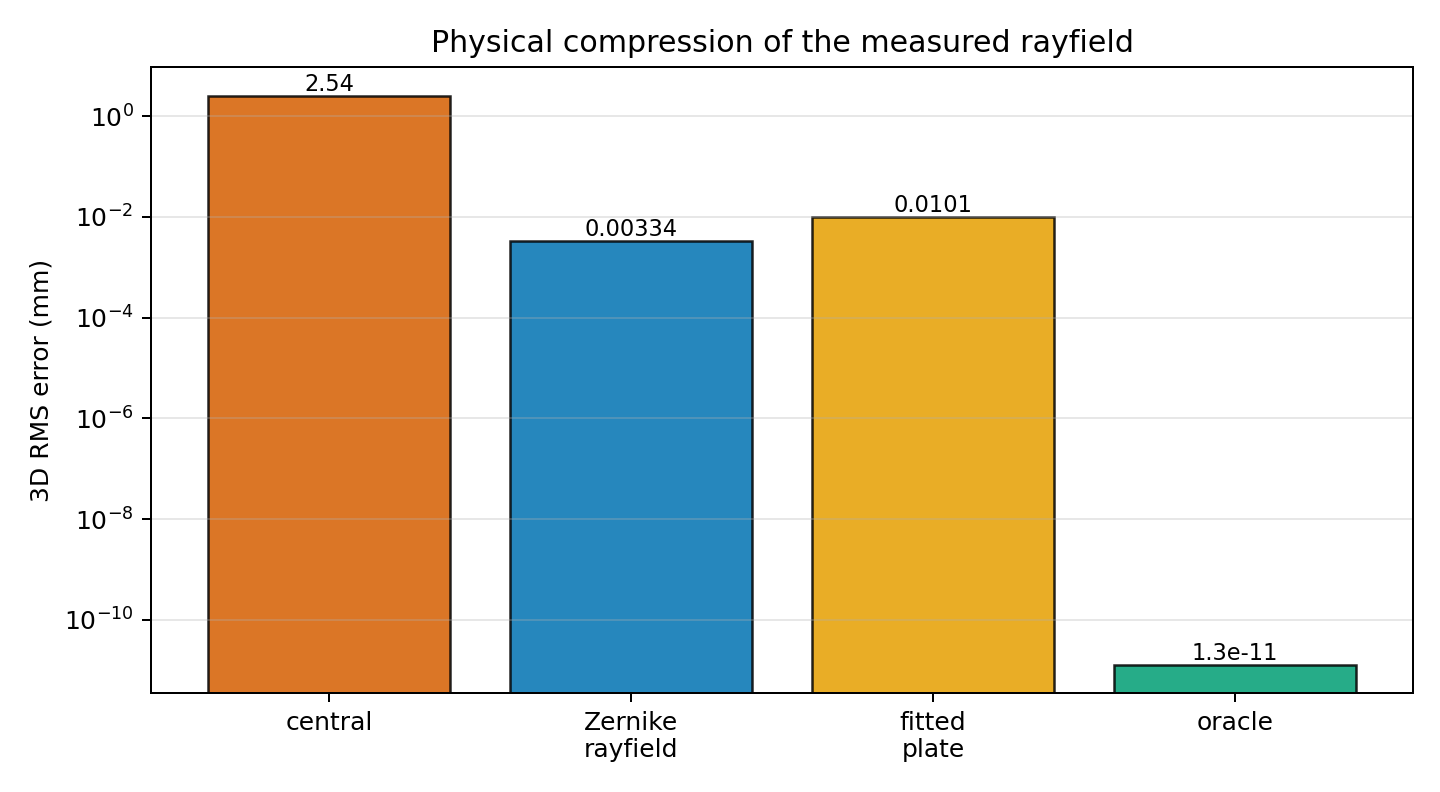

physical_plate_vs_zernike_rayfield_heatmap.png


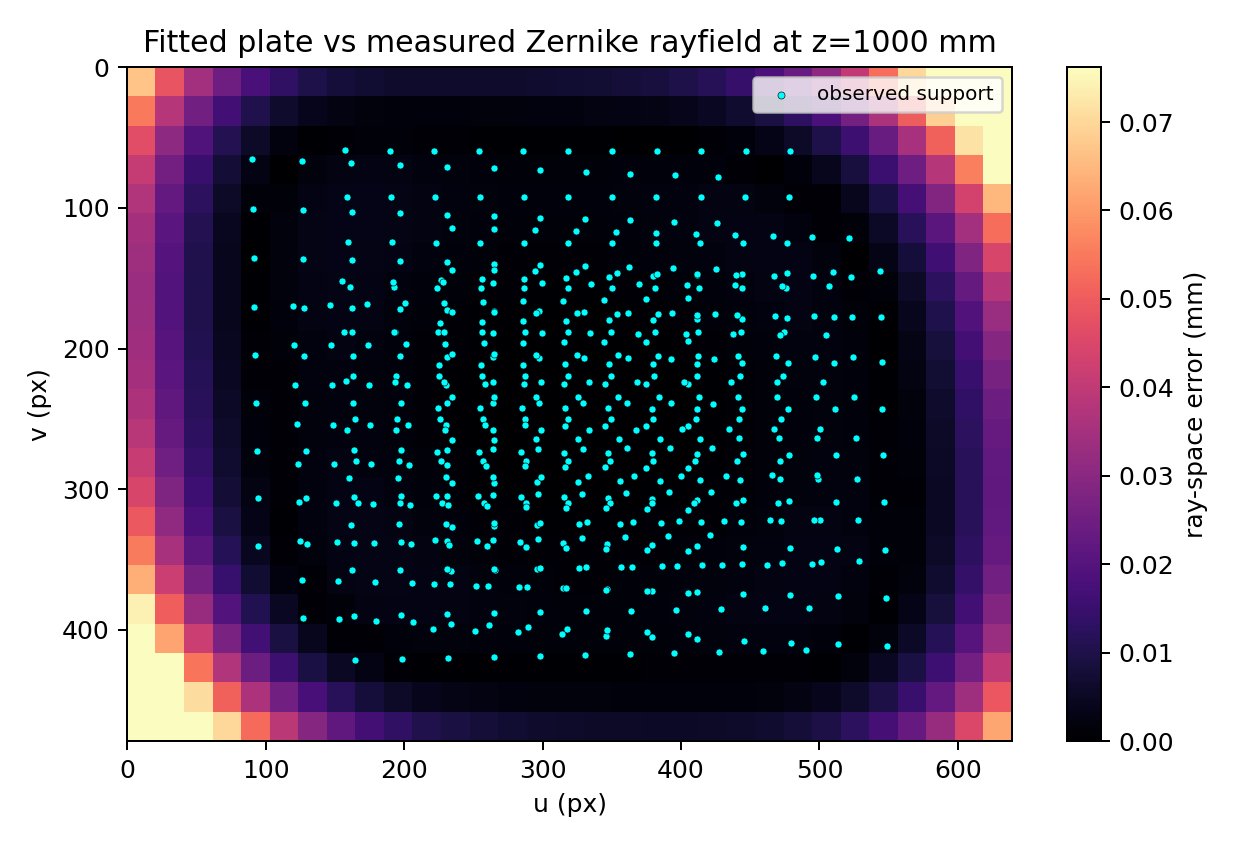

physical_plate_bootstrap_parameters.png


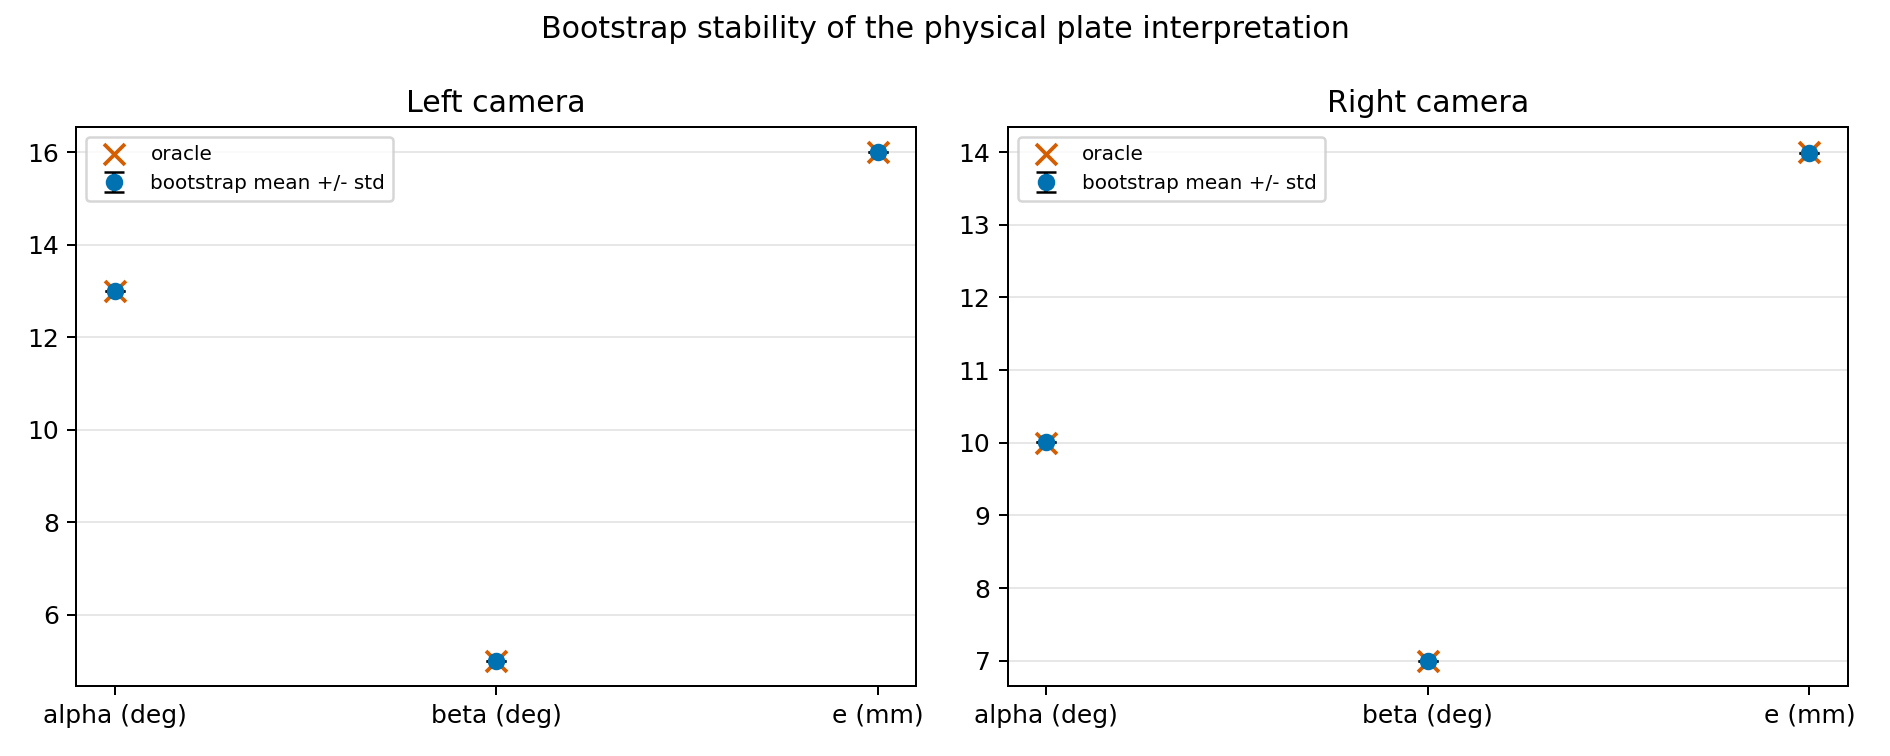

physical_plate_model_selection.png


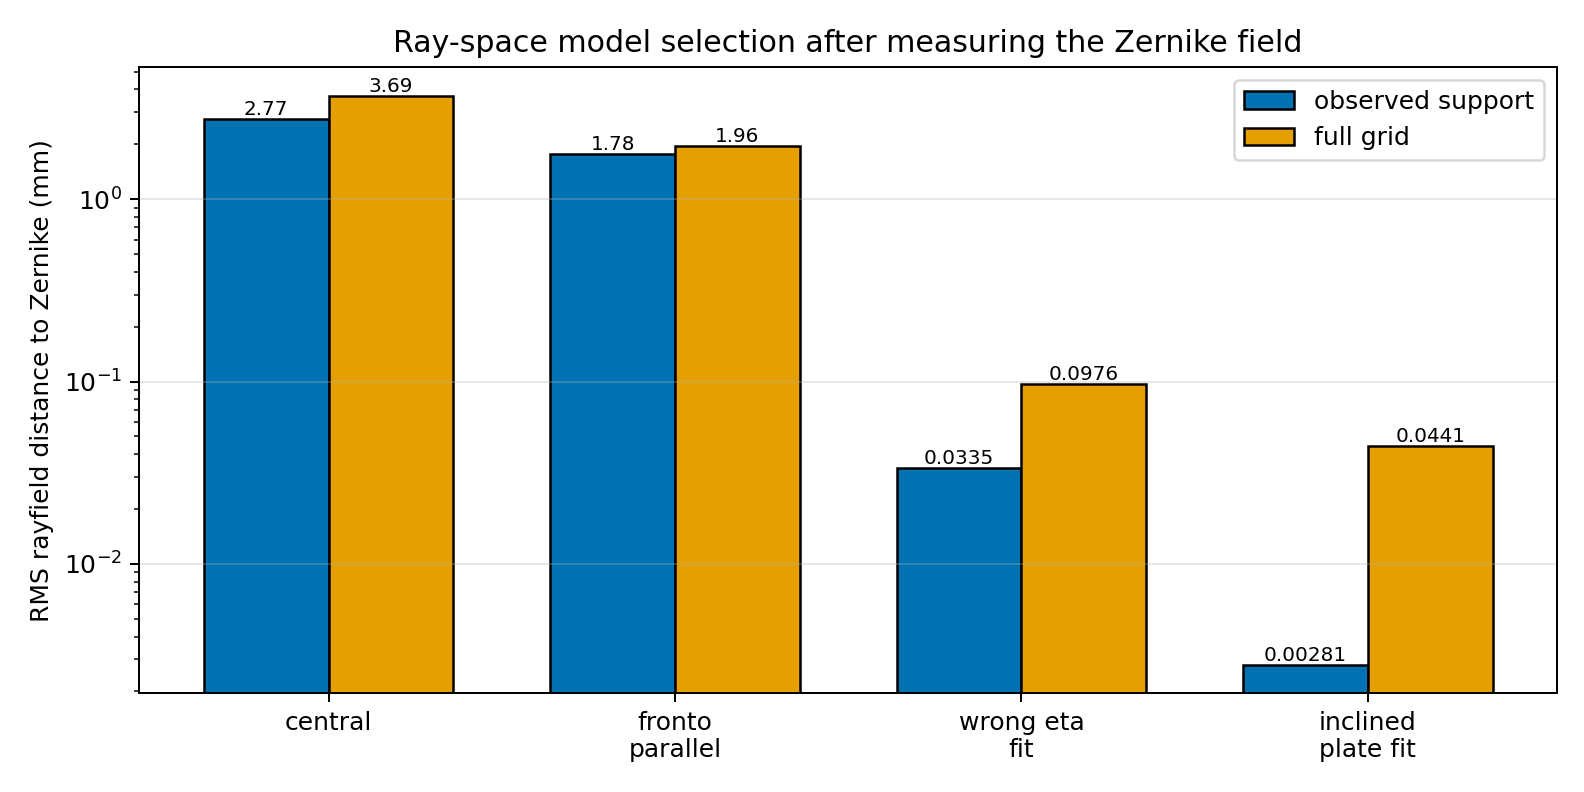

depth_error_map_noise_005px.png


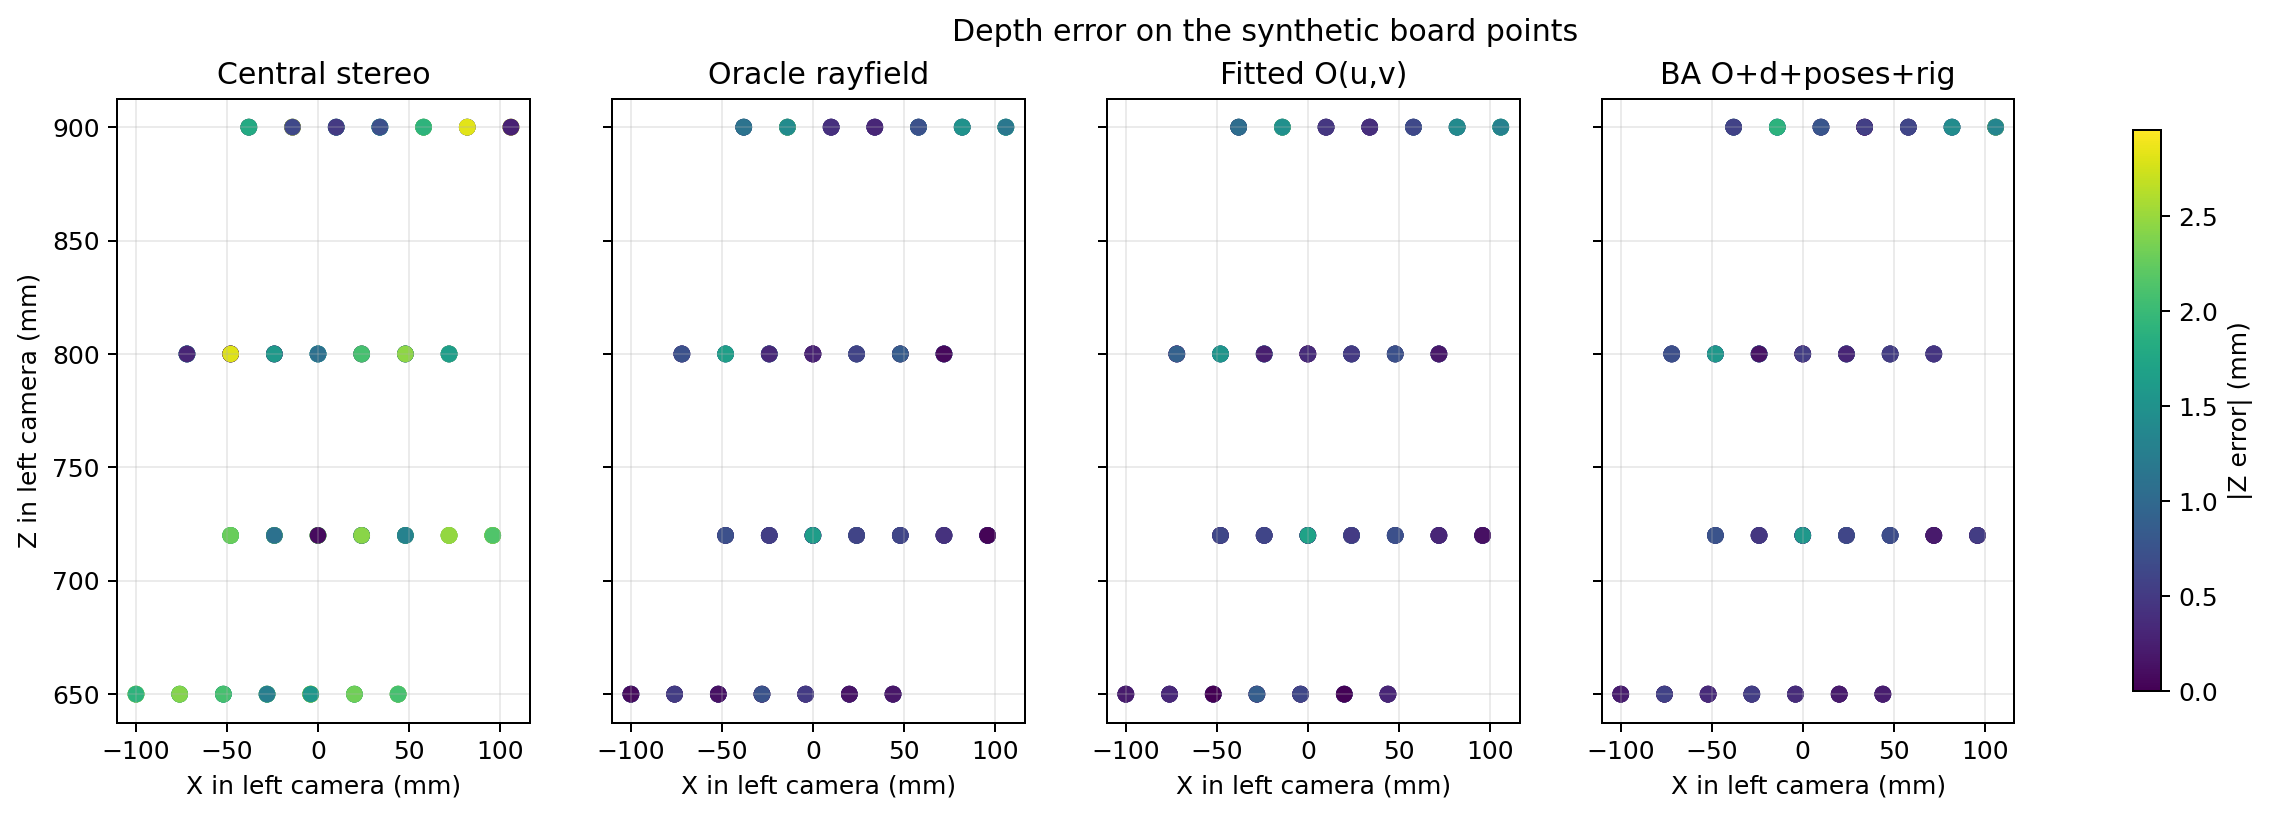

rayfield_plane_error_noise_005px.png


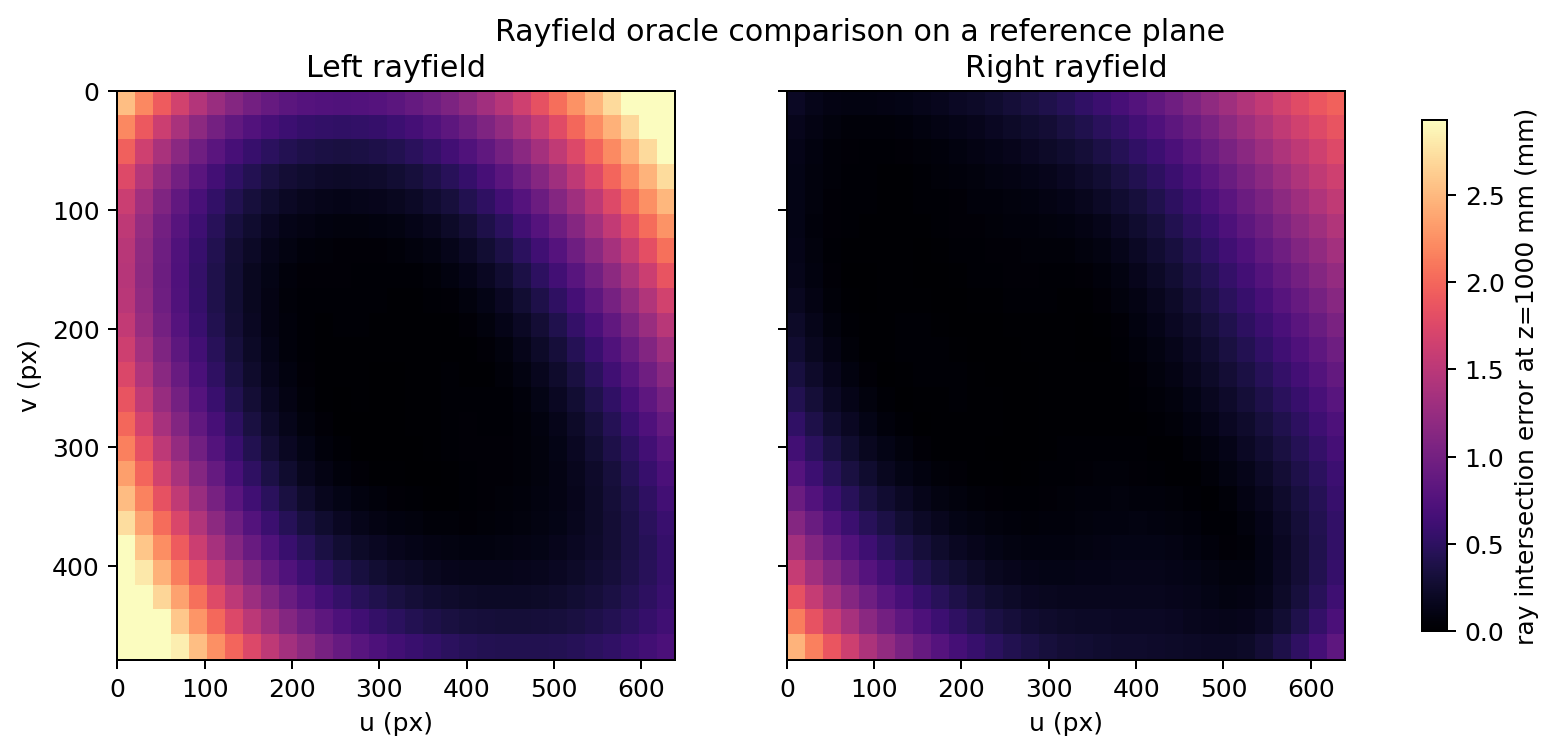

ray_gap_histograms.png


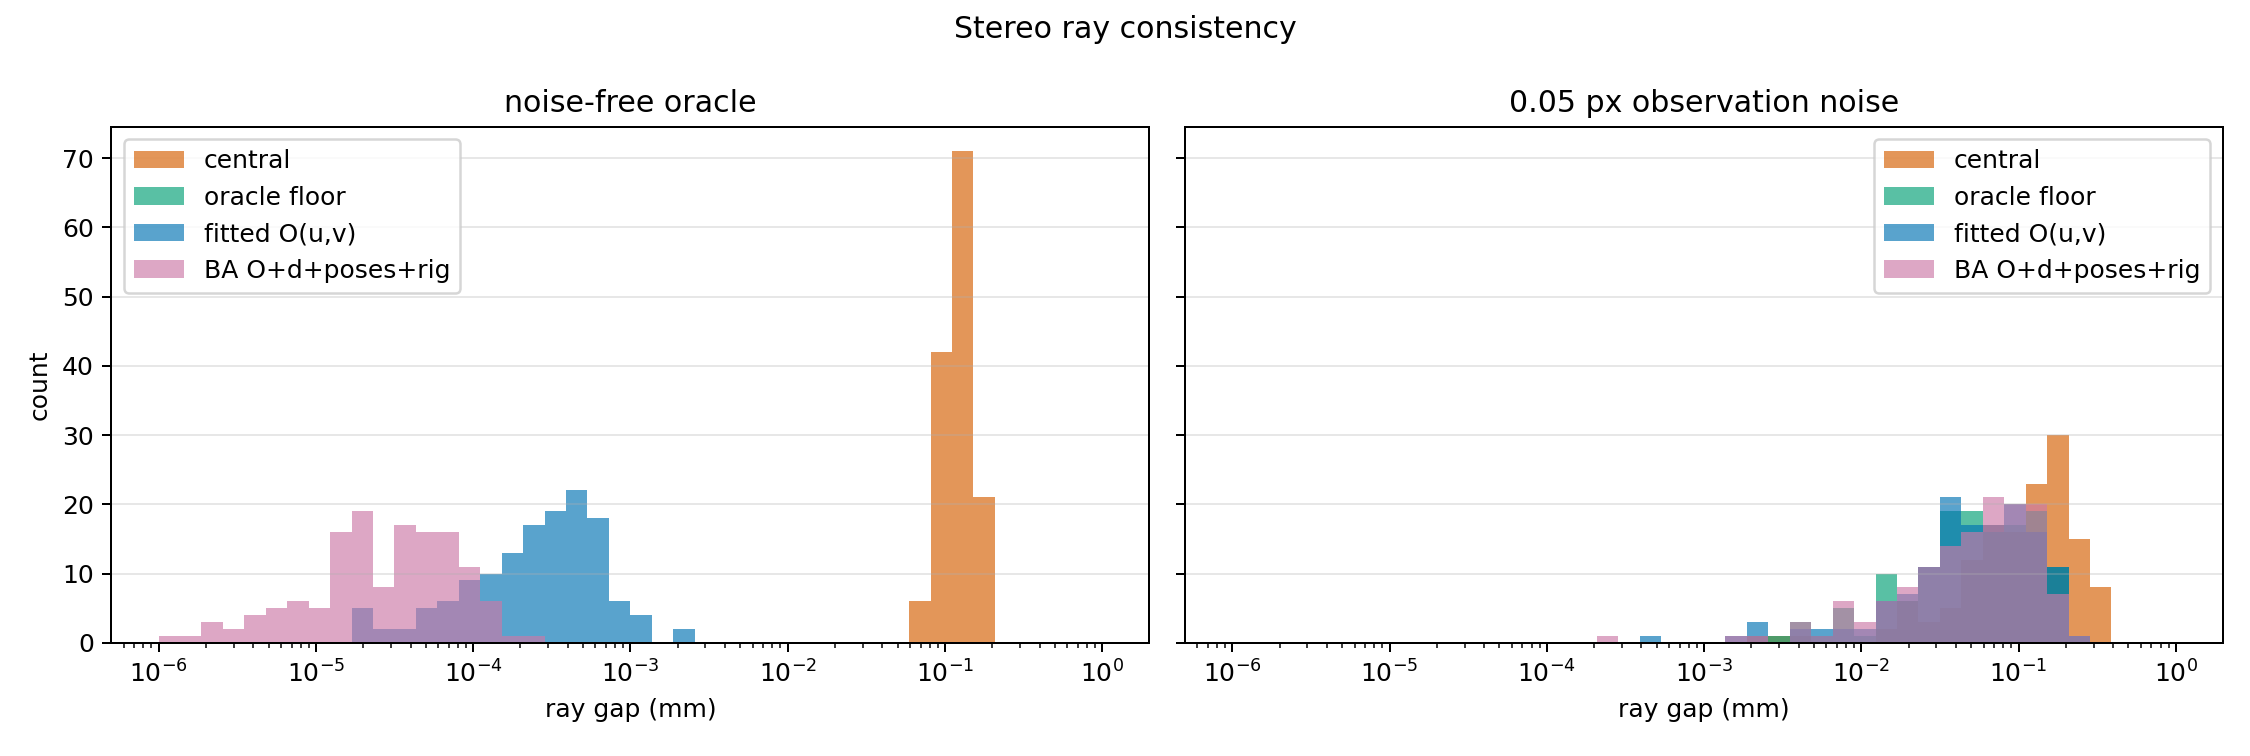

rendered_image_ba/rendered_pair.png


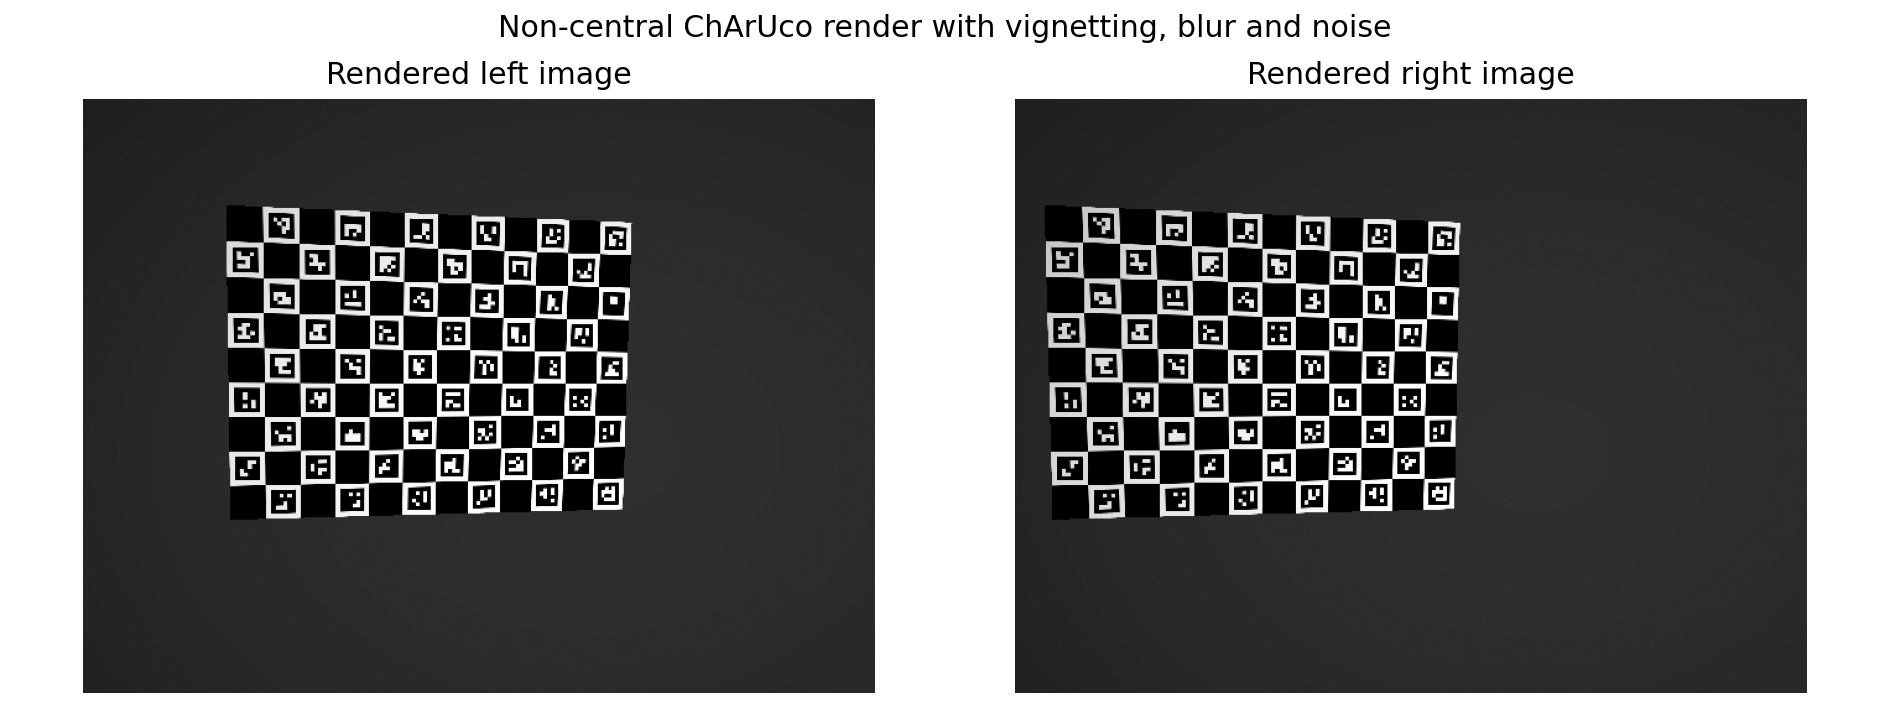

rendered_image_ba/detected_image_ba_rms.png


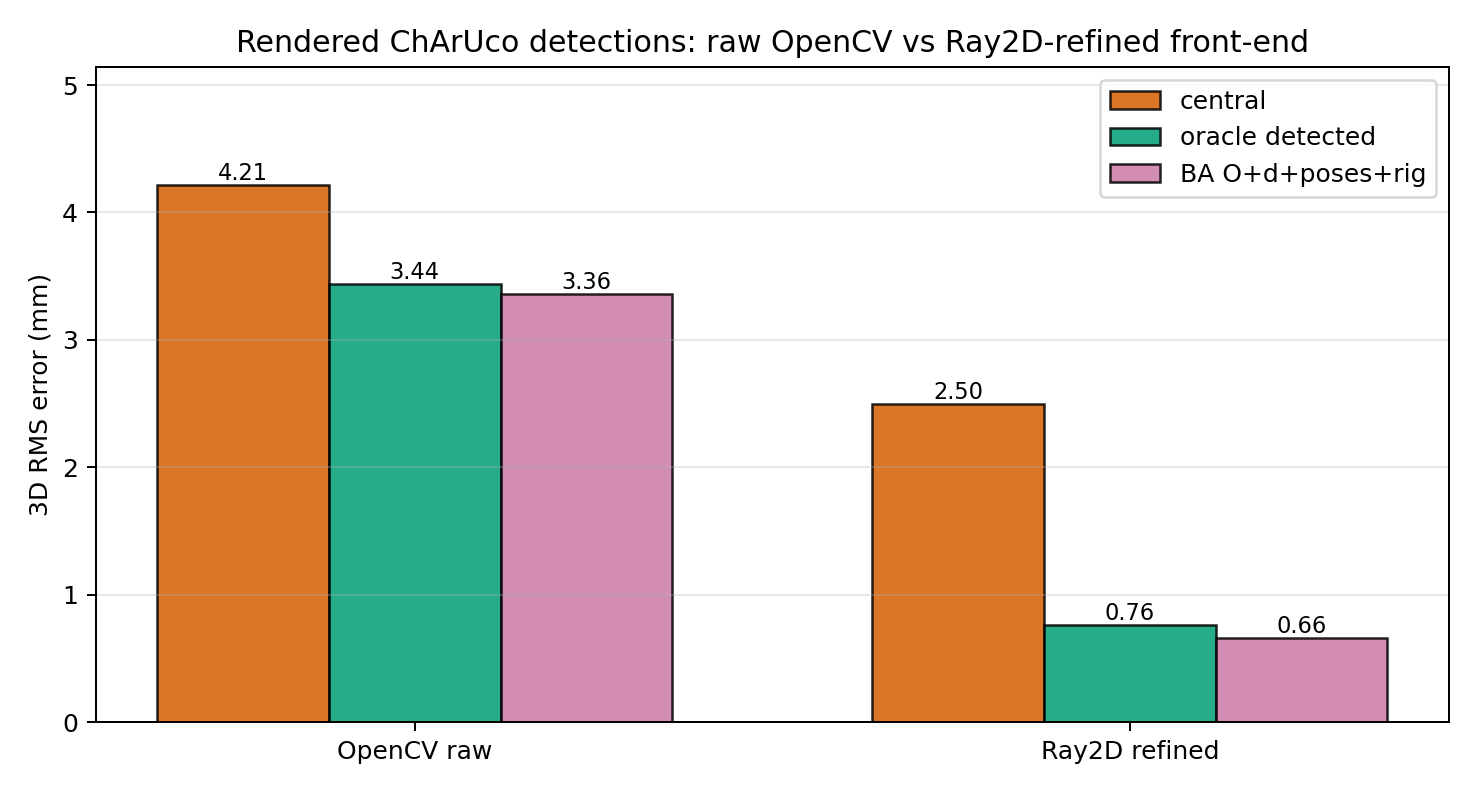

In [9]:
if not ASSET_DIR.exists():
    raise FileNotFoundError(
        f"Missing {ASSET_DIR}. Run docs/examples/parallel_plate_origin_field_demo.py first."
    )

for name in [
    "reconstruction_error_distributions.png",
    "physical_plate_reconstruction_comparison.png",
    "physical_plate_vs_zernike_rayfield_heatmap.png",
    "physical_plate_bootstrap_parameters.png",
    "physical_plate_model_selection.png",
    "depth_error_map_noise_005px.png",
    "rayfield_plane_error_noise_005px.png",
    "ray_gap_histograms.png",
    "rendered_image_ba/rendered_pair.png",
    "rendered_image_ba/detected_image_ba_rms.png",
]:
    print(name)
    display(Image(filename=str(ASSET_DIR / name)))


## 9. Lower-level API: explicit dataset, fit, comparison

The high-level benchmark is convenient, but the lower-level calls are the actual
API pieces. Notice that the fit receives the synthetic observations and initial
geometry, **not** the plate parameters.


In [10]:
dataset = sc.make_default_parallel_plate_dataset(noise_std_px=0.05)
dataset_clean = sc.make_default_parallel_plate_dataset(noise_std_px=0.0)
config = sc.ZernikeOriginFieldConfig(image_size=dataset.image_size, max_order=4)

fit = sc.fit_stereo_zernike_origin_field(
    observations=dataset,
    K_left=dataset.K_left,
    K_right=dataset.K_right,
    T_right_left_initial=dataset.T_right_left,
    board_poses_initial=dataset.board_poses,
    config_left=config,
    config_right=config,
    regularization=1e-3,
)

fit_ba = sc.fit_stereo_zernike_origin_field(
    observations=dataset,
    K_left=dataset.K_left,
    K_right=dataset.K_right,
    T_right_left_initial=dataset.T_right_left,
    board_poses_initial=dataset.board_poses,
    config_left=sc.ZernikeOriginFieldConfig(image_size=dataset.image_size, max_order=3),
    config_right=sc.ZernikeOriginFieldConfig(image_size=dataset.image_size, max_order=3),
    optimize_directions=True,
    optimize_board_poses=True,
    optimize_stereo_extrinsics=True,
    regularization=1e-5,
    direction_regularization=1e-2,
    pose_regularization=10.0,
    rig_regularization=100.0,
    max_nfev=100,
)

comparison = sc.compare_3d_reconstruction_with_without_origin_field(
    dataset=dataset,
    central_model_result=None,
    origin_field_result=fit,
)
comparison_ba = sc.compare_3d_reconstruction_with_without_origin_field(
    dataset=dataset,
    central_model_result=None,
    origin_field_result=fit_ba,
)

oracle_floor = sc.oracle_reconstruction_floor_report(
    dataset_observed=dataset,
    dataset_clean=dataset_clean,
)

left_rayfield = sc.compare_rayfields_on_planes(
    fitted_field=fit.left_field,
    oracle_ray_function=dataset.oracle_left_ray_function,
    image_size=dataset.image_size,
    z_planes=(100.0, 1000.0),
)

print(f"fit success: {fit.success}")
print(f"fit residual RMS: {fit.residual_rms:.4f} mm")
print(f"BA residual RMS: {fit_ba.residual_rms:.4f} mm")
print(f"central RMS 3D: {comparison.central.rms_3d:.3f} mm")
print(f"oracle noisy-pixel RMS 3D: {oracle_floor.oracle_observed_pixels.rms_3d:.3f} mm")
print(f"origin-field RMS 3D: {comparison.with_origin_field.rms_3d:.3f} mm")
print(f"BA O+d+poses+rig RMS 3D: {comparison_ba.with_origin_field.rms_3d:.3f} mm")
print(f"BA rig translation: {fit_ba.stereo_transform[:3, 3]}")
print(f"left rayfield two-plane RMS: {left_rayfield.plane_intersection_rms:.3f} mm")


fit success: True
fit residual RMS: 0.0859 mm
BA residual RMS: 0.0795 mm
central RMS 3D: 2.310 mm
oracle noisy-pixel RMS 3D: 0.801 mm
origin-field RMS 3D: 0.784 mm
BA O+d+poses+rig RMS 3D: 0.760 mm
BA rig translation: [-9.00000007e+01  6.91971446e-08 -1.59294957e-07]
left rayfield two-plane RMS: 1.520 mm


## 10. Bundle-adjustment roadmap: from rendered images to real images

This notebook now validates both the full geometric BA core on image
coordinates and the rendered-image front-end. `O(u,v)`, `d(u,v)`, board poses,
and the stereo rig are all part of the solve. The remaining step is not a new
parameter block; it is validation on held-out poses and real images.

| Stage | Input observations | Unknowns optimized | What it tests |
|---|---|---|---|
| 0. Geometric oracle | synthetic 2D points | `O(u,v)` only | non-central identifiability |
| 1. Image detection | rendered ChArUco images | `O(u,v)` only | detector and rasterization bias |
| 2. Full geometric BA | synthetic image coordinates | `O(u,v)` + `d(u,v)` + board poses + rig | implemented above |
| 3. Detected-image BA | rendered/detected images | same unknowns as stage 2 | implemented above |
| 4. Real-image BA | real images | same unknowns as stage 2 | remaining validation |

The rendered-image result should be read through the front-end comparison.
With raw OpenCV detections, the **oracle detected** floor is several
millimetres, so the dominant limitation is the detector/rasterization
front-end. With `rayfield_tps_robust`, the oracle detected floor and the BA
reconstruction both return to the sub-millimetre scale expected from the
stereo geometry.

The core question for the next stage is therefore:

> on held-out and real images, does the Ray2D front-end plus the same full
> non-central BA remain close to the detected-pixel oracle floor?

The comparison must be made against the oracle noisy-pixel floor, not against
zero error. With `0.05 px` noise in this geometry, the correct target is about
`0.8 mm` RMS.

Two metrics should be added before claiming image-based identification:

- **train/test split by board pose**, so the fitted field is evaluated on held
  out 3D poses;
- **in-support vs full-image rayfield error**, so extrapolation near image
  corners is not confused with identification quality in the calibrated region.

A Plucker-moment variant `m(u,v)=O(u,v)\times d(u,v)` remains a useful
conditioning ablation, but it is no longer the first priority: the current
`O(u,v)` fit is already near the noisy oracle floor.
